In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigqu

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: 

In [3]:
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("roboflow_APIKEY")
rf = Roboflow(api_key=api_key)

# Lanjutkan proses download dataset
project = rf.workspace("tobias-7spce").project("kidney-stone-detection-9j42c-fudnj")
dataset = project.version(1).download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Kidney-stone-detection-1 in yolov12:: 100%|██████████| 7281/7281 [00:00<00:00, 9656.85it/s] 


In [6]:
import os
# Mengaktifkan debugging DDP tingkat detail
os.environ["TORCH_DISTRIBUTED_DEBUG"] = "DETAIL"

from ultralytics import YOLO

if __name__ == '__main__':
    model_path ='yolo12s.pt'
    model = YOLO(model_path)
    
    result = model.train(
            data=f"{dataset.location}/data.yaml",
            epochs=30,
            imgsz=640,
            batch=-1,         
            plots=True,
            val=True,         # tetap matikan validasi tiap epoch demi kestabilan DDP
            patience=10,
        
            optimizer="AdamW", # mengganti ke AdamW yang jauh lebih stabil untuk model Large daripada SGD bawaan
            lr0=0.001,
            weight_decay=5e-4,
            warmup_epochs=3,
            cos_lr=True,


            # augmentasi (medical-safe)
        
            hsv_h=0.0,
            hsv_s=0.2,
            hsv_v=0.3,
            degrees=10,
            translate=0.1,
            scale=0.5,
            shear=2,
            perspective=0.0,
            flipud=0.0, #vertical flip tidak sesuai untuk anatomi CT scan
            fliplr=0.5,
            mosaic=1.0,
            mixup=0.10,
            copy_paste=0.30, #great for small object
            close_mosaic=15,# turn off mosaic for last 15 epochs

            # loss weights
            box=7.5,
            cls=0.5,
            dfl=1.5,
            
    )

SyntaxError: incomplete input (437151911.py, line 21)

In [5]:
import shutil

# Kompres folder 'detect' menjadi file zip
shutil.make_archive('/kaggle/working/semua_hasil_detect', 'zip', '/kaggle/working/runs/detect')
print("Kompresi selesai! Silakan cek panel kanan.")

Kompresi selesai! Silakan cek panel kanan.


In [8]:



if __name__ == '__main__':
    model_path = 'runs/detect/train/weights/best.pt'
    model = YOLO(model_path)
    
    result = model.train(
            data=f"{dataset.location}/data.yaml",
            epochs=30,
            imgsz=640,
            batch=-1,         
            plots=True,
            val=True,       
            patience=10,
        
            optimizer="AdamW", # mengganti ke AdamW yang jauh lebih stabil untuk model Large daripada SGD bawaan
            lr0=5e-4,
            weight_decay=5e-4,
            warmup_epochs=3,
            cos_lr=True,


            # augmentasi (medical-safe)
            hsv_h=0.0,
            hsv_s=0.2,
            hsv_v=0.3,
            degrees=10,
            translate=0.1,
            scale=0.5,
            shear=2,
            perspective=0.0,
            flipud=0.0, #vertical flip is anatomically wrong for CT
            fliplr=0.0,
            mosaic=1.0,
            mixup=0.0,
            copy_paste=0.0, #great for small objects
            close_mosaic=5,# turn off mosaic for last 5 epochs

            # loss weights
            box=7.5,
            cls=0.5,
            dfl=1.5,
            
    )

Ultralytics 8.4.56 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Kidney-stone-detection-1/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.2, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=F

invalid value encountered in less
invalid value encountered in less


                   all        123        325      0.787      0.762      0.775        0.3
Speed: 0.2ms preprocess, 8.0ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/train-3


In [10]:

!cat /kaggle/working/runs/detect/train/args.yaml



task: detect
mode: train
model: yolo12s.pt
data: /kaggle/working/Kidney-stone-detection-1/data.yaml
epochs: 30
time: null
patience: 10
batch: -1
imgsz: 640
save: true
save_period: -1
cache: false
device: null
workers: 8
project: null
name: train
exist_ok: false
pretrained: true
optimizer: AdamW
verbose: true
seed: 0
deterministic: true
single_cls: false
rect: false
cos_lr: true
close_mosaic: 15
resume: false
amp: true
fraction: 1.0
profile: false
freeze: null
multi_scale: 0.0
compile: false
overlap_mask: true
mask_ratio: 4
dropout: 0.0
val: true
split: val
save_json: false
conf: null
iou: 0.7
max_det: 300
half: false
dnn: false
plots: true
end2end: null
source: null
vid_stride: 1
stream_buffer: false
visualize: false
augment: false
agnostic_nms: false
classes: null
retina_masks: false
embed: null
show: false
save_frames: false
save_txt: false
save_conf: false
save_crop: false
show_labels: true
show_conf: true
show_boxes: true
line_width: null
format: torchscript
keras: false
optimize: 

In [9]:

!cat /kaggle/working/runs/detect/train-3/args.yaml

task: detect
mode: train
model: runs/detect/train/weights/best.pt
data: /kaggle/working/Kidney-stone-detection-1/data.yaml
epochs: 30
time: null
patience: 10
batch: -1
imgsz: 640
save: true
save_period: -1
cache: false
device: null
workers: 8
project: null
name: train-3
exist_ok: false
pretrained: true
optimizer: AdamW
verbose: true
seed: 0
deterministic: true
single_cls: false
rect: false
cos_lr: true
close_mosaic: 5
resume: false
amp: true
fraction: 1.0
profile: false
freeze: null
multi_scale: 0.0
compile: false
overlap_mask: true
mask_ratio: 4
dropout: 0.0
val: true
split: val
save_json: false
conf: null
iou: 0.7
max_det: 300
half: false
dnn: false
plots: true
end2end: null
source: null
vid_stride: 1
stream_buffer: false
visualize: false
augment: false
agnostic_nms: false
classes: null
retina_masks: false
embed: null
show: false
save_frames: false
save_txt: false
save_conf: false
save_crop: false
show_labels: true
show_conf: true
show_boxes: true
line_width: null
format: torchscript

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

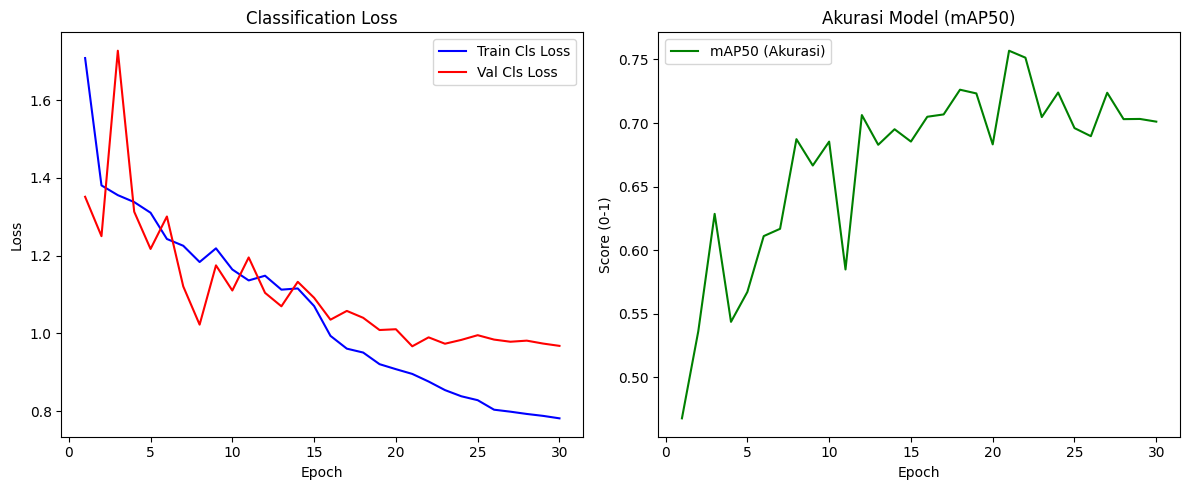

In [13]:


# 1. Baca file results.csv
df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")

# Bersihkan spasi pada nama kolom (YOLO terkadang memberikan spasi di nama kolom)
df.columns = df.columns.str.strip()

# 2. Plot Grafik Loss
plt.figure(figsize=(12, 5))

# Grafik Train vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss", color="blue")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss")
plt.legend()

# Grafik Akurasi (mAP50)
plt.subplot(1, 2, 2)
plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP50 (Akurasi)",
    color="green",
)
plt.xlabel("Epoch")
plt.ylabel("Score (0-1)")
plt.title("Akurasi Model (mAP50)")
plt.legend()

plt.tight_layout()
plt.show()

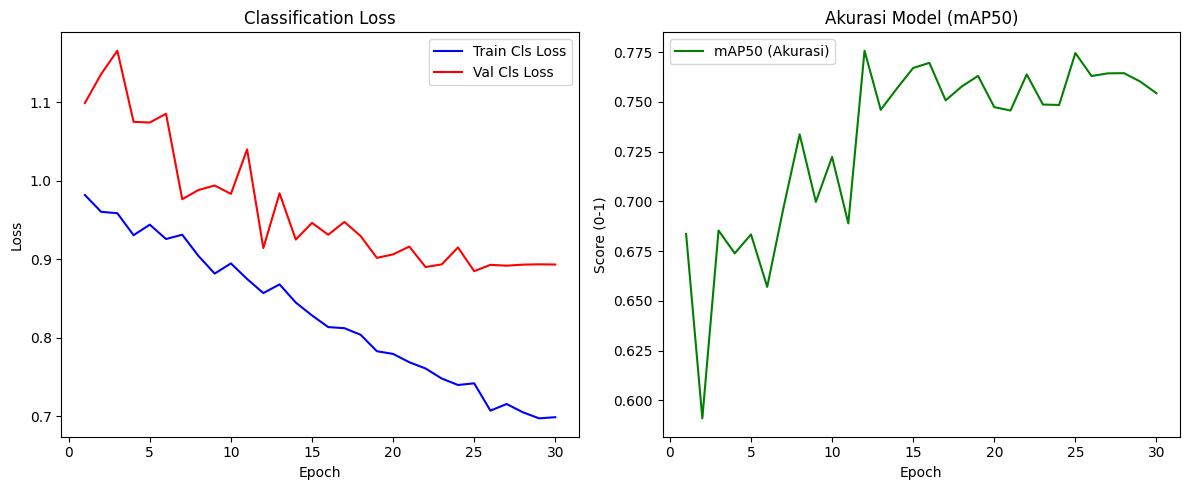

In [12]:


# 1. Baca file results.csv
df = pd.read_csv("/kaggle/working/runs/detect/train-3/results.csv")

# Bersihkan spasi pada nama kolom (YOLO terkadang memberikan spasi di nama kolom)
df.columns = df.columns.str.strip()

# 2. Plot Grafik Loss
plt.figure(figsize=(12, 5))

# Grafik Train vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss", color="blue")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss")
plt.legend()

# Grafik Akurasi (mAP50)
plt.subplot(1, 2, 2)
plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP50 (Akurasi)",
    color="green",
)
plt.xlabel("Epoch")
plt.ylabel("Score (0-1)")
plt.title("Akurasi Model (mAP50)")
plt.legend()

plt.tight_layout()
plt.show()